In [1]:
import os
import numpy as np
import xarray as xr
from skimage.transform import resize
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
DATA_PATH = r"C:\Users\Owner\water_proj\dat"
SAVE_PATH = r"C:\Users\Owner\water_proj\processed"

os.makedirs(SAVE_PATH, exist_ok=True)

files = sorted([
    os.path.join(DATA_PATH, f)
    for f in os.listdir(DATA_PATH)
    if f.endswith(".nc")
])

print("Total files:", len(files))

Total files: 20


In [3]:
TARGET_SHAPE = (32, 32)
SEQ_LEN = 5

def resize_data(arr):
    out = []
    for t in range(arr.shape[0]):
        out.append(resize(arr[t], TARGET_SHAPE, mode='reflect', anti_aliasing=True))
    return np.array(out)

def create_sequences(arr, seq_len=SEQ_LEN):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i:i+seq_len])
        y.append(arr[i+seq_len])
    return np.array(X), np.array(y)

In [4]:
for idx, file in enumerate(files):
    print(f"\nProcessing {idx+1}/{len(files)}:", file)
    
    ds = xr.open_dataset(file)
    data = ds["layer1"]
    
    # California
    cal = data.sel(lat=slice(42, 32), lon=slice(-125, -114))
    
    # Michigan
    mi = data.sel(lat=slice(49, 41), lon=slice(-90, -82))
    
    # LIMIT TIME (SAFE)
    cal = cal.isel(time=slice(0,150))
    mi = mi.isel(time=slice(0,150))
    
    cal_arr = np.nan_to_num(cal.values)
    mi_arr = np.nan_to_num(mi.values)
    
    # Resize
    cal_arr = resize_data(cal_arr)
    mi_arr = resize_data(mi_arr)
    
    # Sequences
    X_ca, y_ca = create_sequences(cal_arr)
    X_mi, y_mi = create_sequences(mi_arr)
    
    X_comb = np.concatenate([X_ca, X_mi], axis=0)
    y_comb = np.concatenate([y_ca, y_mi], axis=0)
    
    # Save per-file (CRITICAL)
    np.save(os.path.join(SAVE_PATH, f"X_{idx}.npy"), X_comb)
    np.save(os.path.join(SAVE_PATH, f"y_{idx}.npy"), y_comb)

print("\nALL FILES PROCESSED")


Processing 1/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2000.nc

Processing 2/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2001.nc

Processing 3/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2002.nc

Processing 4/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2003.nc

Processing 5/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2004.nc

Processing 6/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2005.nc

Processing 7/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2006.nc

Processing 8/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2007.nc

Processing 9/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2008.nc

Processing 10/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2009.nc

Processing 11/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2010.nc

Processing 12/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2011.nc

Processing 13/20: C:\Users\Owner\water_proj\dat\SoMo.ml_v1_layer1_2012.nc

Processing 14/20: C:\Users\Owner\

In [5]:
X_list = []
y_list = []

for f in os.listdir(SAVE_PATH):
    if f.startswith("X_"):
        X_list.append(np.load(os.path.join(SAVE_PATH, f)))
    if f.startswith("y_"):
        y_list.append(np.load(os.path.join(SAVE_PATH, f)))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print("Final dataset:", X.shape, y.shape)

Final dataset: (5800, 5, 32, 32) (5800, 32, 32)


In [10]:
# Add channel dimension for Conv3D
X = X[..., np.newaxis]
y = y[..., np.newaxis]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5800, 5, 32, 32, 1)
y shape: (5800, 32, 32, 1)


In [11]:
mean = X.mean()
std = X.std()

X = (X - mean) / std
y = (y - mean) / std

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [15]:
model = models.Sequential([
    tf.keras.Input(shape=X_train.shape[1:]),

    layers.Conv3D(16, (3,3,3), activation='relu', padding='same'),

    layers.Conv3D(32, (3,3,3), activation='relu', padding='same'),

    layers.Conv3D(1, (1,1,1), activation='linear', padding='same'),

    layers.Lambda(lambda x: x[:, -1])  # take last timestep
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_8 (Conv3D)                    │ (None, 5, 32, 32, 16)       │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_9 (Conv3D)                    │ (None, 5, 32, 32, 32)       │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_10 (Conv3D)                   │ (None, 5, 32, 32, 1)        │              33 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_2 (Lambda)                    │ (None, 32, 32, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=8
)

Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 0.0151 - mae: 0.0605 - val_loss: 0.0023 - val_mae: 0.0304
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0023 - mae: 0.0321 - val_loss: 0.0022 - val_mae: 0.0300
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.0020 - mae: 0.0296 - val_loss: 0.0017 - val_mae: 0.0274
Epoch 4/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.0019 - mae: 0.0285 - val_loss: 0.0016 - val_mae: 0.0251
Epoch 5/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.0019 - mae: 0.0285 - val_loss: 0.0044 - val_mae: 0.0469
Epoch 6/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.0018 - mae: 0.0280 - val_loss: 0.0015 - val_mae: 0.0259
Epoch 7/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.0018 - mae: 0.0276 - val_loss: 0.0020 - val_mae: 0.0310
Epoch 8/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.0018 - mae: 0.0275 - val_loss: 0.0023 - val_mae: 0.0350
Epoch 9/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 

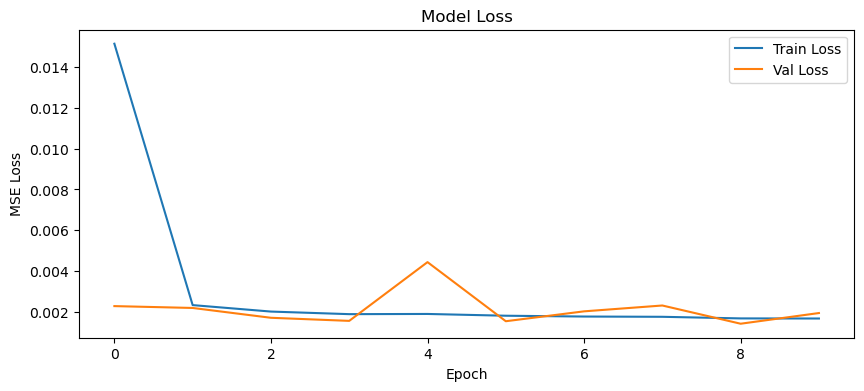

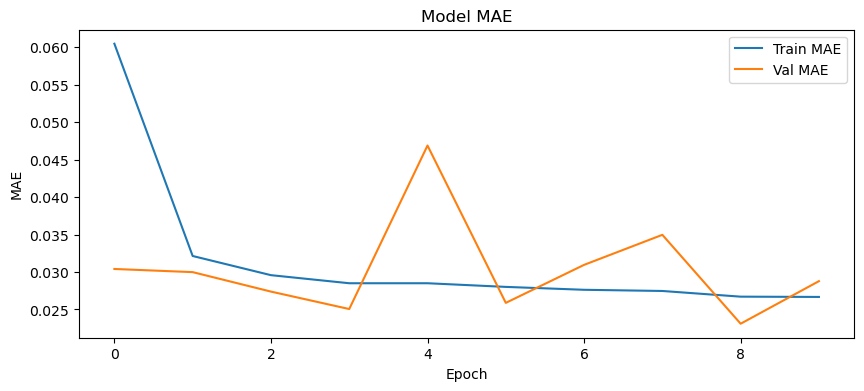

In [17]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# MAE
plt.figure(figsize=(10,4))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title("Model MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


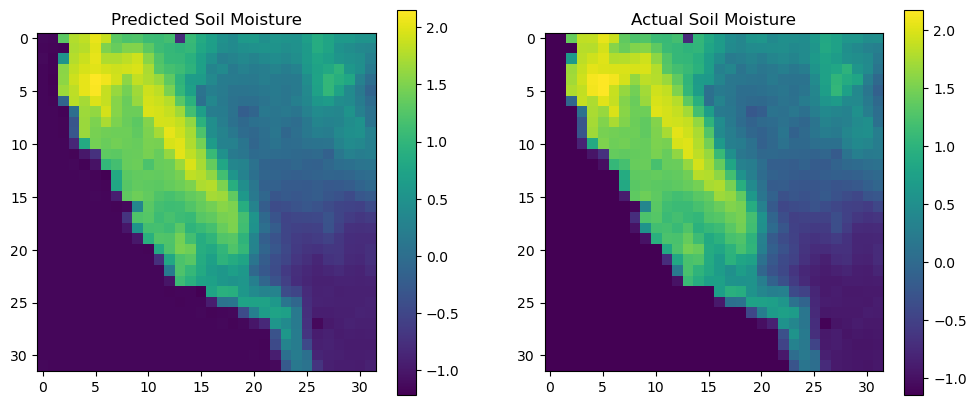

In [18]:
# Predict one sample
pred = model.predict(X_test[:1])

plt.figure(figsize=(12,5))

# Predicted
plt.subplot(1,2,1)
plt.imshow(pred[0, :, :, 0])
plt.title("Predicted Soil Moisture")
plt.colorbar()

# Actual
plt.subplot(1,2,2)
plt.imshow(y_test[0, :, :, 0])
plt.title("Actual Soil Moisture")
plt.colorbar()

plt.show()

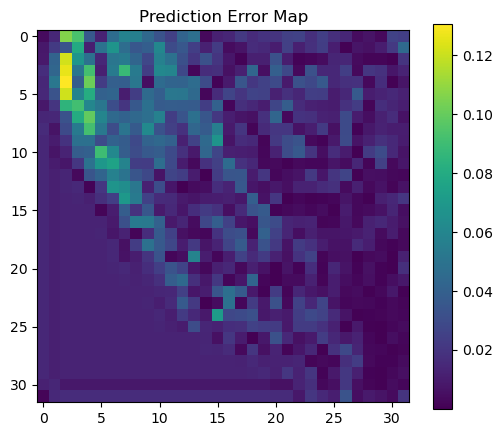

In [19]:
error = abs(pred[0] - y_test[0])

plt.figure(figsize=(6,5))
plt.imshow(error[:, :, 0])
plt.title("Prediction Error Map")
plt.colorbar()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


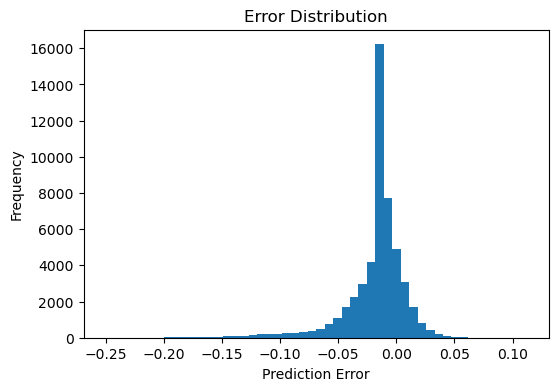

In [20]:
all_preds = model.predict(X_test[:50])

errors = (all_preds - y_test[:50]).flatten()

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

In [22]:
import tensorflow as tf

# Convert directly from the trained model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimization (recommended for mobile)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save TFLite file
with open("soil_moisture_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully!")

INFO:tensorflow:Assets written to: C:\Users\Owner\AppData\Local\Temp\tmph_1iyypm\assets


INFO:tensorflow:Assets written to: C:\Users\Owner\AppData\Local\Temp\tmph_1iyypm\assets


Saved artifact at 'C:\Users\Owner\AppData\Local\Temp\tmph_1iyypm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5, 32, 32, 1), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name=None)
Captures:
  2566444461968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2566444460240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2566444462544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2566444463312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2566444463504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2566444463888: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved successfully!


In [23]:
print("mean =", float(mean))
print("std =", float(std))


mean = 1.2838430052397598e-07
std = 1.0
